> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


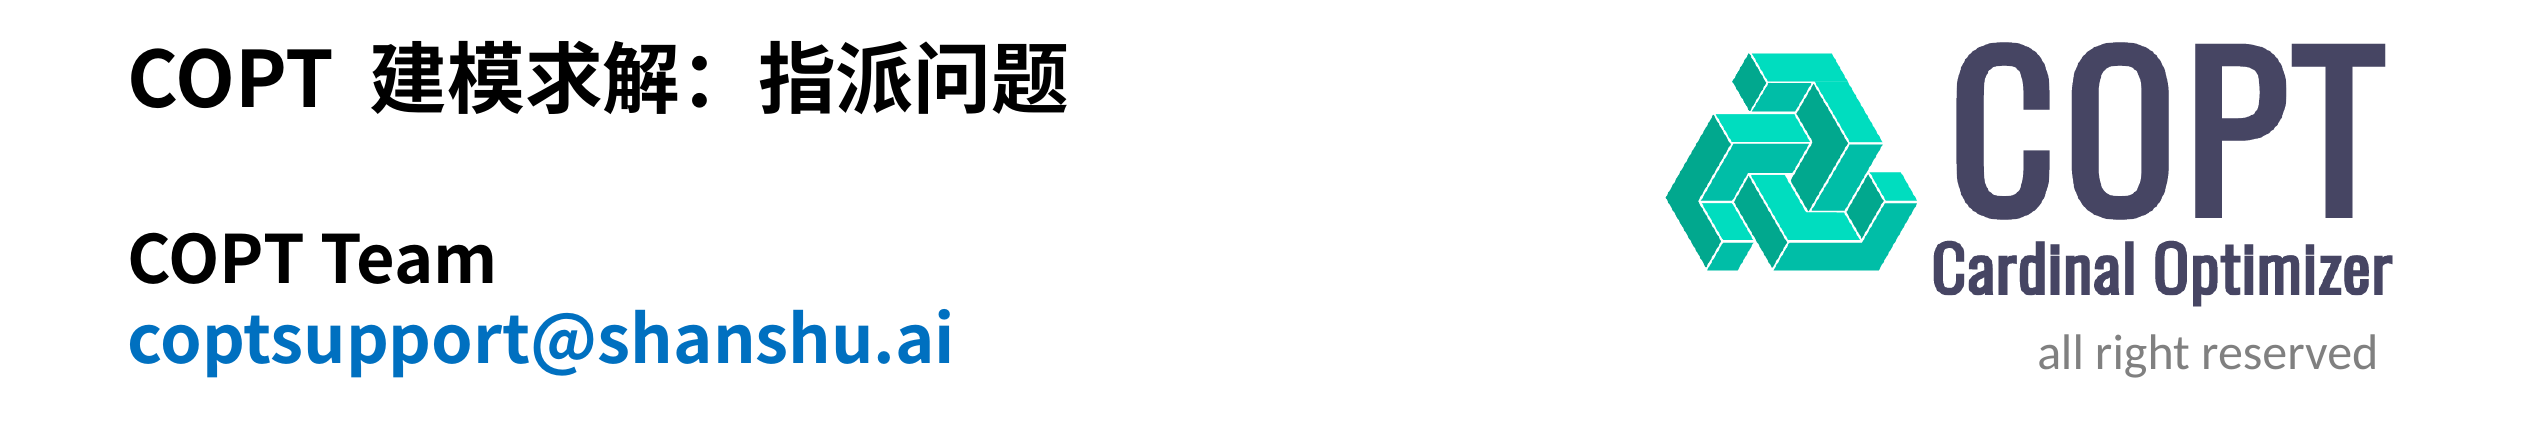

# 指派问题代码实现
## 使用COPT建模求解指派问题的步骤

1. **导入COPT-Python接口库** `coptpy`，以及用于绘图的 `matplotlib`

2. **添加模型数据**：顾问、项目以及每位顾问完成每个项目所需的工作日

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：
        - $x_{ij}$：0-1 变量，顾问 $i$ 负责项目 $j$ 时取 1
    - **目标函数**：工作日总数最少
    - **约束条件**：
        - 每名顾问恰好负责一个项目
        - 每个项目恰好由一名顾问负责

5. **求解**

6. **查看、分析结果**：输出分派方案，与经验做法对比，并验证线性松弛解的整数性

7. **案例拓展**
    - 不平衡指派：项目数多于顾问数，一人最多负责两个项目
    - 瓶颈指派：先最小化最长工期，再最小化总工时

本案例的数学模型与符号含义见案例描述，下面按上述步骤逐段实现。

## 导入COPT-Python接口库
除 `coptpy` 之外，还导入 `matplotlib` 用于绘图，并为图表选择一个可用的中文字体。

In [1]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap

# 中文字体，按系统常见字体依次尝试
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Noto Sans CJK SC', 'Noto Sans CJK JP']:
    if font_name in installed_fonts:
        plt.rcParams['font.sans-serif'] = [font_name]
        break
plt.rcParams['axes.unicode_minus'] = False

# 热力图配色：浅蓝到中蓝，避免深色影响数字可读性
LIGHT_BLUES = LinearSegmentedColormap.from_list('light_blues', ['#eef4fb', '#5d9be3'])

## 添加模型数据
5 名顾问、5 个项目，以及每位顾问完成每个项目所需的工作日。工作日表按"顾问 → 项目"两级组织成字典 `days`，`days['A', 'P3']` 就是 A 完成 P3 所需的天数，对应数学模型中的 $c_{ij}$。

In [2]:
consultants = ['A', 'B', 'C', 'D', 'E']
projects = ['P1', 'P2', 'P3', 'P4', 'P5']

# 每位顾问完成每个项目所需的工作日 c_ij
days_table = [
    [10, 18, 16, 19, 15],
    [ 8, 12, 18, 19, 14],
    [13, 13, 15, 10,  9],
    [ 8,  9, 12,  9, 13],
    [14,  9, 16, 20, 11],
]
days = {(i, j): days_table[a][b] for a, i in enumerate(consultants) for b, j in enumerate(projects)}

## 创建求解环境和求解模型
使用 COPT 建模前需要先创建求解环境 `Envr`，再在环境中创建模型对象 `Model`，之后的变量与约束都添加到这个模型上。

In [3]:
env = cp.Envr()
model = env.createModel("assignment")

Cardinal Optimizer v8.0.6. Build date Aug  7 2026
Copyright Cardinal Operations 2026. All Rights Reserved


## 添加模型三要素

### 添加决策变量
每个"顾问-项目"组合对应一个 0-1 变量 $x_{ij}$。把顾问列表和项目列表一起传给 `addVars()`，COPT 会为两者的每一种组合创建一个变量，并以 `(顾问, 项目)` 作为下标。

In [4]:
x = model.addVars(consultants, projects, vtype=COPT.BINARY, nameprefix='x')

print(f'共创建 {len(x)} 个变量，例如 x["A", "P3"] 的名称为 {x["A", "P3"].name}')

共创建 25 个变量，例如 x["A", "P3"] 的名称为 x(A,P3)


<font color=#0000FF>
<b>提示：用多个下标集合批量创建变量</b>
</font>

`Model.addVars()` 可以接收多个可迭代对象作为下标集合，返回的 `tupledict` 以各集合元素的组合（元组）为键，这里的键就是 `('A', 'P1')`、`('A', 'P2')`、…，共 $5 \times 5 = 25$ 个。变量名由 `nameprefix` 与下标自动拼成 `x(A,P3)` 的形式，与数学模型中的 $x_{ij}$ 一一对应。

`vtype=COPT.BINARY` 指定 0-1 变量，等价于取值范围为 $[0, 1]$ 的整数变量。

### 设置目标函数
目标是工作日总数最少。`tupledict` 的 `prod()` 方法把每个变量与同一下标下的系数相乘后求和，`x.prod(days)` 就是 $\sum_{i,j} c_{ij} x_{ij}$。
$$
\min \, \sum_{i \in I} \sum_{j \in J} c_{ij} \cdot x_{ij}
$$

In [5]:
model.setObjective(x.prod(days), sense=COPT.MINIMIZE)

### 添加约束条件
两组约束：每名顾问恰好负责一个项目，每个项目恰好由一名顾问负责。`x.sum(i, '*')` 表示把顾问 $i$ 对应的所有变量相加（`'*'` 代表该位置的下标任取），`x.sum('*', j)` 同理。
$$
\sum_{j \in J} x_{ij} = 1, \quad \forall \, i \in I \qquad\qquad \sum_{i \in I} x_{ij} = 1, \quad \forall \, j \in J
$$

In [6]:
consultant_cons = model.addConstrs((x.sum(i, '*') == 1 for i in consultants), nameprefix='consultant')
project_cons = model.addConstrs((x.sum('*', j) == 1 for j in projects), nameprefix='project')

print(f'模型规模：{model.getAttr("Rows")} 行约束，{model.getAttr("Cols")} 列变量')

模型规模：10 行约束，25 列变量


<font color=#0000FF>
<b>提示：tupledict 的 sum() 与 prod()</b>
</font>

`addVars()` 返回的 `tupledict` 除了按键取变量，还提供两个常用的聚合方法：

- `x.sum(i, '*')` 对第一个下标为 `i`、第二个下标任意的变量求和，得到一个线性表达式；`x.sum()` 不带参数则对全部变量求和。对于按多个维度组织的变量，这比手写 `quicksum(x[i, j] for j in projects)` 更简洁，也不容易写错下标。
- `x.prod(coeff)` 以字典 `coeff` 为系数对变量做加权求和，`coeff` 的键与变量下标一致。目标函数中的 $\sum c_{ij} x_{ij}$ 用一句 `x.prod(days)` 即可写出。

`Model.addConstrs()` 接受生成器表达式，每产生一项就添加一条约束，`nameprefix` 会自动生成 `consultant(A)` 这样的约束名。

### 查看模型文件
建模完成后，可以把模型导出为 LP 格式的文本文件。LP 文件用接近数学公式的写法列出目标函数、约束和变量类型，是检查模型是否与设想一致最直接的方式。

In [7]:
model.write('assignment.lp')

with open('assignment.lp') as f:
    print(f.read())

\Generated by Cardinal Operations

Minimize
   10 x(A,P1) + 18 x(A,P2) + 16 x(A,P3) + 19 x(A,P4) + 15 x(A,P5) 
   + 8 x(B,P1) + 12 x(B,P2) + 18 x(B,P3) + 19 x(B,P4) + 14 x(B,P5) 
   + 13 x(C,P1) + 13 x(C,P2) + 15 x(C,P3) + 10 x(C,P4) + 9 x(C,P5) 
   + 8 x(D,P1) + 9 x(D,P2) + 12 x(D,P3) + 9 x(D,P4) + 13 x(D,P5) 
   + 14 x(E,P1) + 9 x(E,P2) + 16 x(E,P3) + 20 x(E,P4) + 11 x(E,P5) 
Subject To
 consultant(A): x(A,P1) + x(A,P2) + x(A,P3) + x(A,P4) + x(A,P5) = 1
 consultant(B): x(B,P1) + x(B,P2) + x(B,P3) + x(B,P4) + x(B,P5) = 1
 consultant(C): x(C,P1) + x(C,P2) + x(C,P3) + x(C,P4) + x(C,P5) = 1
 consultant(D): x(D,P1) + x(D,P2) + x(D,P3) + x(D,P4) + x(D,P5) = 1
 consultant(E): x(E,P1) + x(E,P2) + x(E,P3) + x(E,P4) + x(E,P5) = 1
 project(P1): x(A,P1) + x(B,P1) + x(C,P1) + x(D,P1) + x(E,P1) = 1
 project(P2): x(A,P2) + x(B,P2) + x(C,P2) + x(D,P2) + x(E,P2) = 1
 project(P3): x(A,P3) + x(B,P3) + x(C,P3) + x(D,P3) + x(E,P3) = 1
 project(P4): x(A,P4) + x(B,P4) + x(C,P4) + x(D,P4) + x(E,P4) = 1
 pro

<font color=#0000FF>
<b>提示：导出模型文件 Model.write()</b>
</font>

`Model.write(filename)` 根据文件扩展名决定导出格式：`.lp` 为可读性最好的 LP 格式，`.mps` 为求解器间通用的 MPS 格式，`.bin` 为 COPT 自有的二进制格式；求解后还可以用 `.sol` 导出解、`.bas` 导出基。导出的 LP 文件里可以清楚看到 25 个变量分属两组约束、系数全为 1，也可以看到变量名与约束名正是 `nameprefix` 生成的形式。

调试模型时，先导出 LP 文件对照数学公式检查一遍，往往比直接看求解结果更容易发现建模错误。

## 求解

In [8]:
model.solve()

Model fingerprint: 2624400

Using Cardinal Optimizer v8.0.6 on Linux (Ubuntu 24.04.4 LTS - x86_64)
The CPU model is Intel(R) Xeon(R) Processor @ 2.80GHz
Hardware has 2 physical cores and 2 logical cores. Using instruction set X86_AVX512_E1 (14)
Minimizing a MIP problem

The original problem has:
    10 rows, 25 columns and 50 non-zero elements
    25 binaries

Starting the MIP solver with 2 threads and 4 tasks

Presolving the problem

The presolved problem has:
    10 rows, 25 columns and 50 non-zero elements
    25 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [8e+00,2e+01]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.02s
H        0         1      --       0  0.0

<font color=#0000FF>
<b>提示：如何阅读 COPT 的求解日志</b>
</font>

日志开头给出模型规模（`10 rows, 25 columns`，25 个 0-1 变量）和预处理后的规模。对于整数规划，日志的核心是分支定界表格：`BestBound` 是当前能证明的下界，`BestSolution` 是当前找到的最好整数解，`Gap` 是二者的相对差距，降到 0 即证明最优。

本模型的日志中，根节点的线性松弛解本身就是整数解，分支定界不需要展开任何子节点，这正是案例描述中所说的指派问题线性松弛解的整数性。日志末尾 `Solution status : integer optimal` 表示求得整数最优解，代码中可通过 `model.status == COPT.OPTIMAL` 判断。

## 获取结果
求解完成后，变量的属性 `x[i, j].x` 就是它在最优解中的取值（求解之前这个属性没有意义），取值为 1 的组合就是分派结果；目标函数的最优值通过 `model.objval` 读取。下面先输出分派方案，再画成热力图。热力图中每个格子对应一个"顾问-项目"组合，格中的数字是所需工作日，蓝色越深表示工作日越多（右侧色条为对应刻度）；橙色方框标出被选中的组合，每行、每列各有且只有一个。后文的热力图沿用同一种画法。为了对照，同时计算案例描述中提到的经验做法——按顺序让每位顾问挑自己最快的剩余项目。

经验做法（每人挑自己最快的剩余项目）：
  A → P1：10 个工作日
  B → P2：12 个工作日
  C → P5：9 个工作日
  D → P4：9 个工作日
  E → P3：16 个工作日
  合计 56 个工作日

COPT 最优方案：
  A → P3：16 个工作日
  B → P1：8 个工作日
  C → P5：9 个工作日
  D → P4：9 个工作日
  E → P2：9 个工作日
  合计 51 个工作日


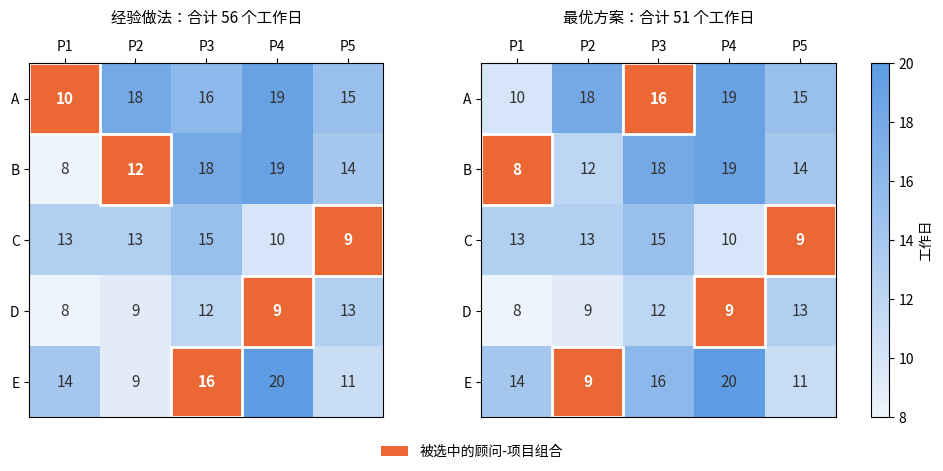

In [9]:
def get_assignment(x):
    """从变量取值中读出分派结果，返回 {顾问: 项目列表}"""
    result = {}
    for (i, j), var in x.items():
        if var.x > 0.5:
            result.setdefault(i, []).append(j)
    return result


def print_assignment(assignment, days, title):
    total = 0
    print(title)
    for i in consultants:
        for j in assignment.get(i, []):
            print(f'  {i} → {j}：{days[i, j]} 个工作日')
            total += days[i, j]
        if not assignment.get(i):
            print(f'  {i} → 无')
    print(f'  合计 {total} 个工作日\n')
    return total


def plot_assignment(ax, days, rows, cols, assignment, title):
    """工作日热力图，方框标出被选中的顾问-项目组合"""
    matrix = [[days[i, j] for j in cols] for i in rows]
    im = ax.imshow(matrix, cmap=LIGHT_BLUES, vmin=min(map(min, matrix)), vmax=max(map(max, matrix)))
    for a, i in enumerate(rows):
        for b, j in enumerate(cols):
            if j in assignment.get(i, []):
                ax.add_patch(plt.Rectangle((b - 0.5, a - 0.5), 1, 1, facecolor='#eb6834', edgecolor='white', linewidth=2))
                ax.text(b, a, str(days[i, j]), ha='center', va='center', fontsize=11, color='white', fontweight='bold')
            else:
                ax.text(b, a, str(days[i, j]), ha='center', va='center', fontsize=11, color='#333333')
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(rows)
    ax.xaxis.set_ticks_position('top')
    ax.set_title(title, fontsize=11, pad=12)
    return im


# 经验做法：按顺序让每位顾问挑自己最快的剩余项目
remaining = list(projects)
greedy = {}
for i in consultants:
    j = min(remaining, key=lambda p: days[i, p])
    greedy[i] = [j]
    remaining.remove(j)

if model.status == COPT.OPTIMAL:
    optimal = get_assignment(x)
    total_greedy = print_assignment(greedy, days, '经验做法（每人挑自己最快的剩余项目）：')
    total_opt = print_assignment(optimal, days, 'COPT 最优方案：')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
    plot_assignment(ax1, days, consultants, projects, greedy, f'经验做法：合计 {total_greedy} 个工作日')
    im = plot_assignment(ax2, days, consultants, projects, optimal, f'最优方案：合计 {total_opt} 个工作日')
    fig.colorbar(im, ax=[ax1, ax2], fraction=0.03, pad=0.04, label='工作日')
    fig.legend([plt.Rectangle((0, 0), 1, 1, facecolor='#eb6834')], ['被选中的顾问-项目组合'],
               loc='lower center', frameon=False)
    plt.show()
else:
    print('未找到最优解，求解状态：', model.status)

最优方案共 51 个工作日，比经验做法的 56 天少 5 天。对比两张热力图可以看出差别在哪里：经验做法前四位顾问都拿到了各自最快的项目，把 P3 留给了并不擅长它的 E（16 天）；最优方案则让 A 去做 P3（16 天，A 并不是做 P3 最快的人），换来 B、C、D、E 都拿到 8 至 9 天的项目。A 一个人多花的时间，被其他四人省下的时间抵消还有余，这就是全局最优与逐个局部最优的差别。

从热力图还能看到，最优方案选中的 5 个格子颜色都不深，没有一个是所在行或所在列的最大值，但也并非每个都是所在行的最小值——最优解追求的是整体之和最小，而不是每一步最小。

### 验证线性松弛解的整数性
案例描述中提到，指派问题的线性松弛解一定是整数。下面把 25 个变量的类型从 0-1 改为连续型（取值范围 $[0, 1]$），在同一个模型上重新求解，看结果是否仍然是 0-1 的。

In [10]:
for var in model.getVars():
    var.setType(COPT.CONTINUOUS)

model.setParam("Logging", 0)
model.solve()

values = sorted(var.x for var in model.getVars())
print(f'线性松弛的目标值：{model.objval}')
print(f'25 个变量在最优解中的取值：{[round(v, 4) for v in values]}')
print('松弛解与整数模型的分派方案一致：', get_assignment(x) == optimal)

# 恢复为 0-1 变量，后面的拓展仍以整数模型为基础
for var in model.getVars():
    var.setType(COPT.BINARY)

线性松弛的目标值：51.0
25 个变量在最优解中的取值：[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0]
松弛解与整数模型的分派方案一致： True


<font color=#0000FF>
<b>提示：修改变量类型 Var.setType()</b>
</font>

`Var.setType()` 可以在建模之后修改变量类型，取值为 `COPT.CONTINUOUS`、`COPT.INTEGER` 或 `COPT.BINARY`。把整数变量改为连续型再求解，就是手动做一次线性松弛；反过来改回整数型即恢复原模型，不需要重新建模。

这里还用 `setParam("Logging", 0)` 关闭了求解日志。COPT 的参数名可以直接用字符串给出，不区分大小写。

线性松弛的目标值同样是 51，25 个变量在最优解中的取值仍然全是 0 或 1，分派方案与整数模型完全相同。这说明对指派问题而言，整数要求实际上是"多余"的——线性规划的最优顶点解天然就是一种合法的分派。日志中根节点直接得到整数解，也是同一原因。

## 案例拓展一：不平衡指派
公司又接到第 6 个项目 P6，5 名顾问完成它所需的工作日分别为 12、17、11、15、14 天，并允许一名顾问最多负责两个项目。与标准模型相比，只有顾问一侧的约束从"等于 1"改为"不超过 2"。

In [11]:
projects6 = projects + ['P6']
days6 = dict(days)
for i, d in zip(consultants, [12, 17, 11, 15, 14]):
    days6[i, 'P6'] = d

model6 = env.createModel("unbalanced_assignment")
model6.setParam("Logging", 0)
x6 = model6.addVars(consultants, projects6, vtype=COPT.BINARY, nameprefix='x')
model6.setObjective(x6.prod(days6), sense=COPT.MINIMIZE)
model6.addConstrs((x6.sum(i, '*') <= 2 for i in consultants), nameprefix='consultant')
model6.addConstrs((x6.sum('*', j) == 1 for j in projects6), nameprefix='project')
model6.solve()

assign_le2 = get_assignment(x6)
total_le2 = print_assignment(assign_le2, days6, '每人最多两个项目：')

每人最多两个项目：
  A → 无
  B → P1：8 个工作日
  C → P5：9 个工作日
  C → P6：11 个工作日
  D → P3：12 个工作日
  D → P4：9 个工作日
  E → P2：9 个工作日
  合计 58 个工作日


最省工时的方案是 C 和 D 各负责两个项目，A 一个项目都没有分到。从效率看这很合理——A 在多数项目上都是最慢的；但从团队管理看，让一名顾问完全闲置未必可取。下面在同一个模型上追加一组"每人至少负责一个项目"的约束，看看总工时要为此增加多少。

每人最多两个、至少一个项目：
  A → P6：12 个工作日
  B → P1：8 个工作日
  C → P5：9 个工作日
  D → P3：12 个工作日
  D → P4：9 个工作日
  E → P2：9 个工作日
  合计 59 个工作日


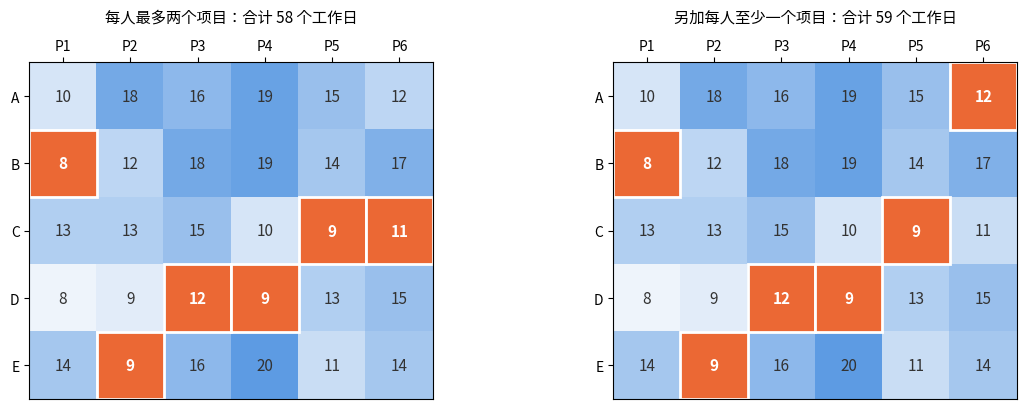

In [12]:
model6.addConstrs((x6.sum(i, '*') >= 1 for i in consultants), nameprefix='at_least_one')
model6.solve()

assign_ge1 = get_assignment(x6)
total_ge1 = print_assignment(assign_ge1, days6, '每人最多两个、至少一个项目：')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
plot_assignment(ax1, days6, consultants, projects6, assign_le2, f'每人最多两个项目：合计 {total_le2} 个工作日')
plot_assignment(ax2, days6, consultants, projects6, assign_ge1, f'另加每人至少一个项目：合计 {total_ge1} 个工作日')
plt.tight_layout()
plt.show()

<font color=#0000FF>
<b>提示：在已求解的模型上追加约束</b>
</font>

`Model.addConstrs()` 可以在模型求解之后继续调用，新增的约束会直接加入原模型，再次 `solve()` 即可得到新的结果，不需要重新建模。这种方式适合"在基础方案上逐步加入管理要求，观察每条要求的代价"这类分析：本例追加一组约束后重新求解，即得到"每人至少一个项目"的方案，可直接与之前的结果对比。

加上"每人至少一个项目"之后，A 承担 P6（12 天），其余分派不变，总工时从 58 天增加到 59 天。也就是说，让团队每个人都参与进来，代价只有 1 个工作日。管理要求的代价，通过在模型上增加约束、比较前后的目标值即可量化。

## 案例拓展二：瓶颈指派
若 5 个项目同时启动，客户关心的是最后一个项目何时完成，目标应改为最小化各项目工期的最大值。按案例描述中的建模方法，引入辅助变量 $z$ 表示最长工期，并要求 $z \geq c_{ij} x_{ij}$ 对所有组合成立。

只以 $z$ 为目标可能存在多个最优方案，它们的总工时不同。这里用 COPT 的分层多目标功能同时给出两个目标：优先级高的是最长工期 $z$，优先级低的是总工时，求解器会先把 $z$ 压到最小，再在 $z$ 不变的前提下使总工时最小。

In [13]:
model_b = env.createModel("bottleneck_assignment")
model_b.setParam("Logging", 0)
xb = model_b.addVars(consultants, projects, vtype=COPT.BINARY, nameprefix='x')
z = model_b.addVar(name='max_days')             # 最长工期

model_b.addConstrs((xb.sum(i, '*') == 1 for i in consultants), nameprefix='consultant')
model_b.addConstrs((xb.sum('*', j) == 1 for j in projects), nameprefix='project')
model_b.addConstrs((z >= days[i, j] * xb[i, j] for i in consultants for j in projects), nameprefix='max_days')

model_b.setObjectiveN(0, z, priority=2)             # 第一目标：最长工期最短
model_b.setObjectiveN(1, xb.prod(days), priority=1)  # 第二目标：总工时最少
model_b.solve()

assign_b = get_assignment(xb)
print(f'最长工期：{model_b.getObjectiveN(0).getValue():.0f} 个工作日，'
      f'总工时：{model_b.getObjectiveN(1).getValue():.0f} 个工作日\n')
total_b = print_assignment(assign_b, days, '瓶颈指派方案：')

最长工期：12 个工作日，总工时：55 个工作日

瓶颈指派方案：
  A → P1：10 个工作日
  B → P2：12 个工作日
  C → P4：10 个工作日
  D → P3：12 个工作日
  E → P5：11 个工作日
  合计 55 个工作日


<font color=#0000FF>
<b>提示：分层多目标 Model.setObjectiveN()</b>
</font>

`Model.setObjectiveN(index, expr, priority=..., weight=...)` 为模型添加第 `index` 个目标函数。`priority` 越大越先优化：COPT 先求出高优先级目标的最优值，再把它作为约束固定下来，在此基础上优化下一个目标，因此低优先级目标绝不会以牺牲高优先级目标为代价。同一优先级的多个目标则按 `weight` 加权合成一个目标。求解后用 `Model.getObjectiveN(index).getValue()` 读取各目标的取值。

若只关心最长工期，也可以用普通的 `setObjective(z)`；加入第二目标的意义在于，在最长工期相同的多个方案中挑出总工时最少的那个，避免结果依赖于求解器的搜索顺序。

最后把两种目标下的方案放在一起比较：左图为各顾问的项目工期，右图为分派热力图。

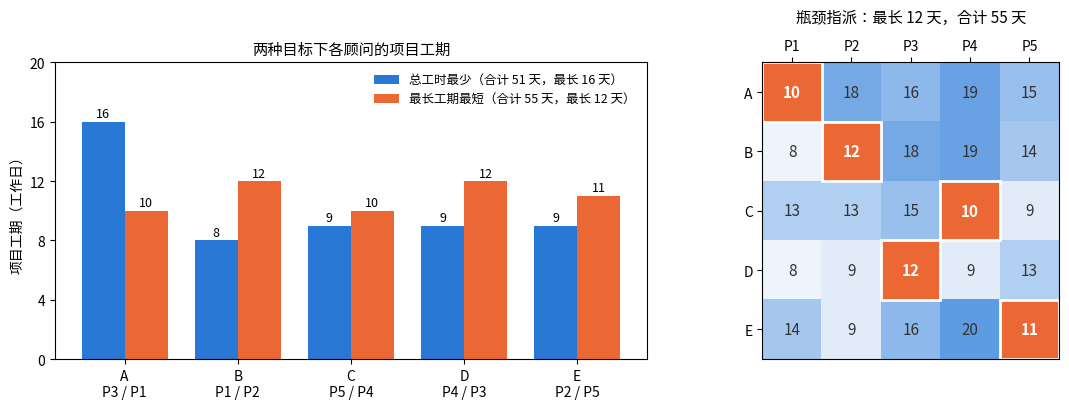

In [14]:
days_opt = [days[i, optimal[i][0]] for i in consultants]
days_bn = [days[i, assign_b[i][0]] for i in consultants]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={'width_ratios': [1.1, 1]})
w = 0.38
pos = range(len(consultants))
ax1.bar([p - w / 2 for p in pos], days_opt, w, color='#2a78d6', label=f'总工时最少（合计 {sum(days_opt)} 天，最长 {max(days_opt)} 天）')
ax1.bar([p + w / 2 for p in pos], days_bn, w, color='#eb6834', label=f'最长工期最短（合计 {sum(days_bn)} 天，最长 {max(days_bn)} 天）')
for p, (a, b) in enumerate(zip(days_opt, days_bn)):
    ax1.text(p - w / 2, a + 0.3, str(a), ha='center', fontsize=9)
    ax1.text(p + w / 2, b + 0.3, str(b), ha='center', fontsize=9)
ax1.set_xticks(list(pos))
ax1.set_xticklabels([f'{i}\n{optimal[i][0]} / {assign_b[i][0]}' for i in consultants])
ax1.set_ylabel('项目工期（工作日）')
ax1.set_ylim(0, 20)
ax1.set_yticks(range(0, 21, 4))
ax1.set_title('两种目标下各顾问的项目工期', fontsize=11)
ax1.legend(frameon=False, fontsize=9)
plot_assignment(ax2, days, consultants, projects, assign_b, f'瓶颈指派：最长 {max(days_bn)} 天，合计 {sum(days_bn)} 天')
plt.tight_layout()
plt.show()

两种目标给出的方案完全不同。总工时最少的方案里，A 负责 P3 要 16 天，其他四人只需 8 至 9 天，项目完成时间参差不齐；瓶颈指派方案把每个人的工期都控制在 10 至 12 天之间，最后一个项目在第 12 个工作日完成，比原方案提前 4 天，代价是总工时从 51 天增加到 55 天。

哪种方案更好取决于公司的目标：按人天计费、顾问可以陆续释放去做其他项目，总工时最少更合适；客户要求所有项目同步交付，则应选择瓶颈指派。模型的作用是把这两种选择的代价量化出来——4 个工作日的总工时，换来最晚交付提前 4 天——供管理者决策。